# Calibración de modelos de clasificación

El rendimiento de un modelo para el dominio de la salud no se agota en el área bajo la curva ROC (AUC-ROC). Un modelo puede ordenar perfectamente a los pacientes de mayor a menor riesgo y tener un AUC de 0.90, pero si para un grupo con riesgo predicho del 70% la tasa real de eventos es del 25%, el modelo está descalibrado. Si un intensivista o un comité de triaje toma decisiones de admisión a UCI con base en probabilidades nominales, una mala calibración induce sobretratamiento o abandono terapéutico.

**Problema:** Estimación del riesgo de evento adverso en cuidados críticos. El objetivo central no es ordenar pacientes (discriminación), sino obtener probabilidades insesgadas para dosificar soporte invasivo sin provocar iatrogenia.

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    brier_score_loss,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split


In [50]:
np.random.seed(42)
n_samples = 6000

edad = np.random.normal(62, 12, n_samples).clip(18, 95).round()
presion_arterial_media = np.random.normal(75, 14, n_samples)
lactato = np.random.exponential(1.8, n_samples)
creatinina = np.random.lognormal(0.2, 0.4, n_samples)

log_odds = (
    -4.5 
    + 0.03 * edad 
    - 0.04 * presion_arterial_media 
    + 0.65 * lactato 
    + 0.50 * creatinina
)
prob_real = 1 / (1 + np.exp(-log_odds))
evento_adverso = np.random.binomial(1, prob_real)

df_salud = pd.DataFrame({
    'edad': edad,
    'pam': presion_arterial_media,
    'lactato': lactato,
    'creatinina': creatinina,
    'evento': evento_adverso
})

df_salud.head()

,edad,pam,lactato,creatinina,evento
0,68.0,59.402861,0.848297,0.874261,0
1,60.0,66.166968,1.551492,0.641422,0
2,70.0,61.811157,1.039367,1.054580,0
3,80.0,67.328059,0.031497,1.913986,0
4,59.0,72.001896,9.208113,1.587855,1


Procedemos a entrenar un modelo de boosting que prediga eventos adversos:

In [51]:
X = df_salud.drop(columns='evento')
y = df_salud['evento']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

In [52]:
model = HistGradientBoostingClassifier(
    random_state=42,
    #class_weight='balanced',
    )

randon_search = RandomizedSearchCV(
    estimator=model,
    param_distributions={
        'learning_rate': [0.01, 0.05, 0.1],
        'max_iter': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'min_samples_leaf': [20, 50, 100]
    },
    n_iter=10,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

randon_search.fit(X_train, y_train)

base_model = randon_search.best_estimator_

print(classification_report(y_test, base_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1138
           1       0.57      0.21      0.31        62

    accuracy                           0.95      1200
   macro avg       0.76      0.60      0.64      1200
weighted avg       0.94      0.95      0.94      1200



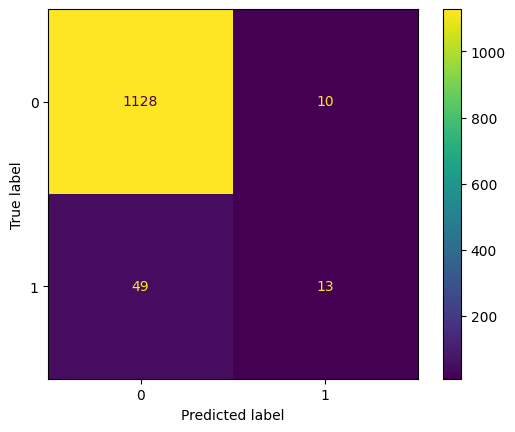

In [53]:
ConfusionMatrixDisplay.from_estimator(base_model, X_test, y_test);

Observamos que este modelo tiene muy baja sensitividad.

In [54]:
print("Prevalencia real de eventos:", y_test.mean())

probs_raw = randon_search.best_estimator_.predict_proba(X_test)[:, 1]
print("AUC-ROC del modelo base:", roc_auc_score(y_test, probs_raw))
print("Brier Score del modelo base:", brier_score_loss(y_test, probs_raw))

Prevalencia real de eventos: 0.051666666666666666
AUC-ROC del modelo base: 0.8788267475480469
Brier Score del modelo base: 0.040374198627848266


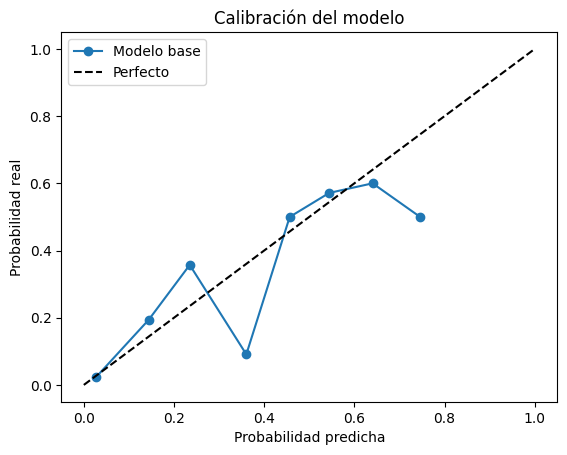

In [55]:
prob_true, prob_pred = calibration_curve(y_test, probs_raw, n_bins=10)

plt.plot(prob_pred, prob_true, "o-", label="Modelo base")
plt.plot([0, 1], [0, 1], "k--", label="Perfecto")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Probabilidad real")
plt.title("Calibración del modelo")
plt.legend()
plt.show()

Las métricas parecen buenas, pero la curva de calibración muestra que el modelo está severamente descalibrado.

Vamos a observar que ocurre si aplicamos una técnica de balanceo de clases:

In [56]:
model = HistGradientBoostingClassifier(
    random_state=42,
    class_weight='balanced',
    )

randon_search = RandomizedSearchCV(
    estimator=model,
    param_distributions={
        'learning_rate': [0.01, 0.05, 0.1],
        'max_iter': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'min_samples_leaf': [20, 50, 100]
    },
    n_iter=10,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

randon_search.fit(X_train, y_train)

base_model = randon_search.best_estimator_

print(classification_report(y_test, base_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.85      0.91      1138
           1       0.21      0.74      0.33        62

    accuracy                           0.84      1200
   macro avg       0.60      0.79      0.62      1200
weighted avg       0.94      0.84      0.88      1200



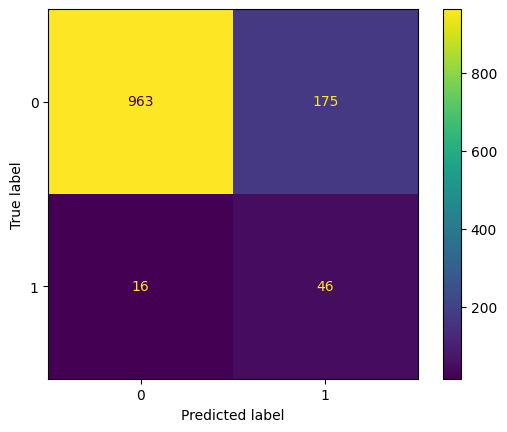

In [57]:
ConfusionMatrixDisplay.from_estimator(base_model, X_test, y_test);

La sensitividad del modelo aumenta drásticamente.

In [58]:
print("Prevalencia real de eventos:", y_test.mean())

probs_raw = randon_search.best_estimator_.predict_proba(X_test)[:, 1]
print("AUC-ROC del modelo base:", roc_auc_score(y_test, probs_raw))
print("Brier Score del modelo base:", brier_score_loss(y_test, probs_raw))

Prevalencia real de eventos: 0.051666666666666666
AUC-ROC del modelo base: 0.8731929247689779
Brier Score del modelo base: 0.13395486315048627


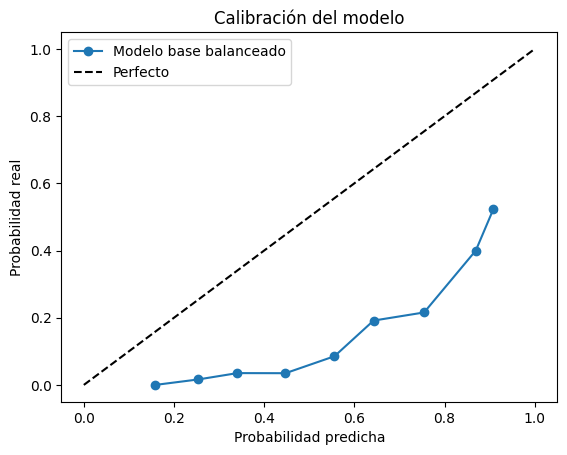

In [59]:
prob_true, prob_pred = calibration_curve(y_test, probs_raw, n_bins=10)

plt.plot(prob_pred, prob_true, "o-", label="Modelo base balanceado")
plt.plot([0, 1], [0, 1], "k--", label="Perfecto")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Probabilidad real")
plt.title("Calibración del modelo")
plt.legend()
plt.show()

Nótese como este modelo sobreestima de manera consistente las pseudo-probabilidades de la clase minoritaria.

In [60]:
# Crear un dataframe con las probabilidades predichas, los resultados predichos y los resultados reales
df_calibracion = pd.DataFrame({
    'probabilidad_predicha': probs_raw,
    'resultado_predicho': randon_search.best_estimator_.predict(X_test),
    'resultado_real': y_test
})

df_calibracion.head(10)

,probabilidad_predicha,resultado_predicho,resultado_real
2675,0.113060,0,0
2626,0.283934,0,0
3011,0.478893,0,0
1236,0.313900,0,0
3621,0.912899,1,0
5217,0.301153,0,0
5555,0.221741,0,0
3087,0.122285,0,0
5178,0.425720,0,0
3990,0.119897,0,0


## Calibración del modelo

In [61]:
modelo_calibrado = CalibratedClassifierCV(
    estimator=base_model, 
    cv=5, 
    method='sigmoid'
    )

modelo_calibrado.fit(X_train, y_train)

probs_cal = modelo_calibrado.predict_proba(X_test)[:, 1]

print("=== EVALUACIÓN DEL MODELO CALIBRADO ===")
print(f"Prevalencia real de eventos: {y_test.mean():.2%}")
print(f"ROC-AUC (Base):       {roc_auc_score(y_test, probs_raw):.4f}")
print(f"ROC-AUC (Calibrado):  {roc_auc_score(y_test, probs_cal):.4f}")
print(f"Brier Score (Base):      {brier_score_loss(y_test, probs_raw):.4f} (menor es mejor)")
print(f"Brier Score (Calibrado): {brier_score_loss(y_test, probs_cal):.4f} (menor es mejor)")

=== EVALUACIÓN DEL MODELO CALIBRADO ===
Prevalencia real de eventos: 5.17%
ROC-AUC (Base):       0.8732
ROC-AUC (Calibrado):  0.8802
Brier Score (Base):      0.1340 (menor es mejor)
Brier Score (Calibrado): 0.0401 (menor es mejor)


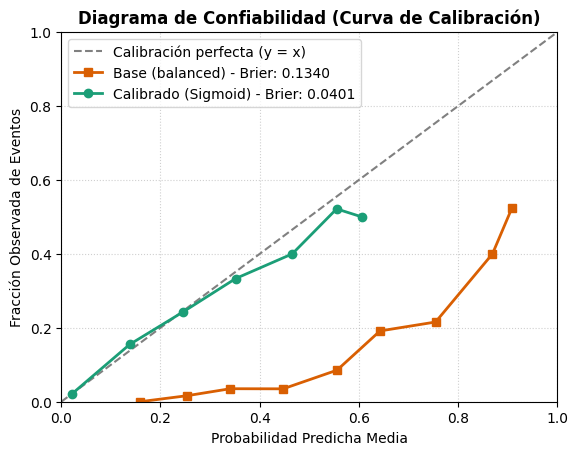

In [62]:
frac_pos_base, mean_pred_base = calibration_curve(y_test, probs_raw, n_bins=10, strategy='uniform')
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, probs_cal, n_bins=10, strategy='uniform')

# 1. Diagrama de Confiabilidad

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibración perfecta (y = x)')
plt.plot(mean_pred_base, frac_pos_base, marker='s', linewidth=2, color='#d95f02', 
             label=f'Base (balanced) - Brier: {brier_score_loss(y_test, probs_raw):.4f}')
plt.plot(mean_pred_cal, frac_pos_cal, marker='o', linewidth=2, color='#1b9e77', 
             label=f'Calibrado (Sigmoid) - Brier: {brier_score_loss(y_test, probs_cal):.4f}')

plt.title('Diagrama de Confiabilidad (Curva de Calibración)', fontweight='bold')
plt.xlabel('Probabilidad Predicha Media')
plt.ylabel('Fracción Observada de Eventos')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', frameon=True)

In [63]:
print(classification_report(y_test, modelo_calibrado.predict(X_test)))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1138
           1       0.52      0.23      0.31        62

    accuracy                           0.95      1200
   macro avg       0.74      0.61      0.64      1200
weighted avg       0.94      0.95      0.94      1200



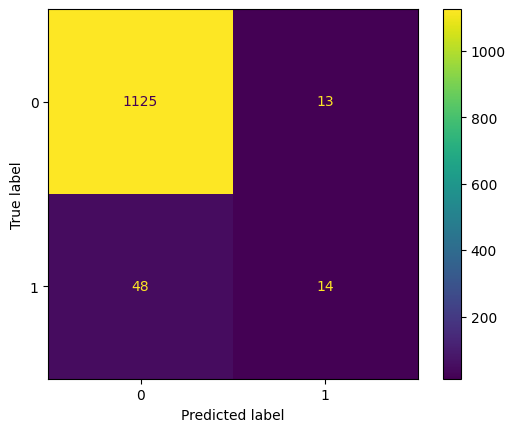

In [64]:
ConfusionMatrixDisplay.from_estimator(modelo_calibrado, X_test, y_test);

La calibración daña la sensitividad del modelo.

Al calibrar el modelo, predecir con el umbral estándar $\tau = 0.5$ colapsa el recall porque los eventos tienen prevalencia de solo 5%.

En salud, el umbral operativo debe elegirse a partir de la razón de costos clínicos (FN vs FP).

In [65]:
thresholds = [0.05, 0.10, 0.20, 0.30, 0.50]
eval_thresholds = []
    
for t in thresholds:
    preds_t = (probs_cal >= t).astype(int)
    rep = classification_report(y_test, preds_t, output_dict=True, zero_division=0)
    eval_thresholds.append({
        'Umbral (tau)': t,
        'Precision (Clase 1)': rep['1']['precision'],
        'Recall / Sensibilidad (Clase 1)': rep['1']['recall'],
        'F1-Score (Clase 1)': rep['1']['f1-score'],
        'Total Alertas Generadas': int(preds_t.sum())
    })

df_thresholds = pd.DataFrame(eval_thresholds)
print("=== COMPORTAMIENTO SEGÚN EL UMBRAL CLÍNICO (MODELO CALIBRADO) ===")
print(df_thresholds.to_string(index=False))

=== COMPORTAMIENTO SEGÚN EL UMBRAL CLÍNICO (MODELO CALIBRADO) ===
 Umbral (tau)  Precision (Clase 1)  Recall / Sensibilidad (Clase 1)  F1-Score (Clase 1)  Total Alertas Generadas
         0.05             0.186508                         0.758065            0.299363                      252
         0.10             0.263514                         0.629032            0.371429                      148
         0.20             0.363636                         0.451613            0.402878                       77
         0.30             0.475000                         0.306452            0.372549                       40
         0.50             0.518519                         0.225806            0.314607                       27


In [66]:
# Modelo final con umbral de 0.05
preds_final = (probs_cal >= 0.05).astype(int)

print("=== EVALUACIÓN DEL MODELO FINAL ===")
print(classification_report(y_test, preds_final))

=== EVALUACIÓN DEL MODELO FINAL ===
              precision    recall  f1-score   support

           0       0.98      0.82      0.89      1138
           1       0.19      0.76      0.30        62

    accuracy                           0.82      1200
   macro avg       0.59      0.79      0.60      1200
weighted avg       0.94      0.82      0.86      1200



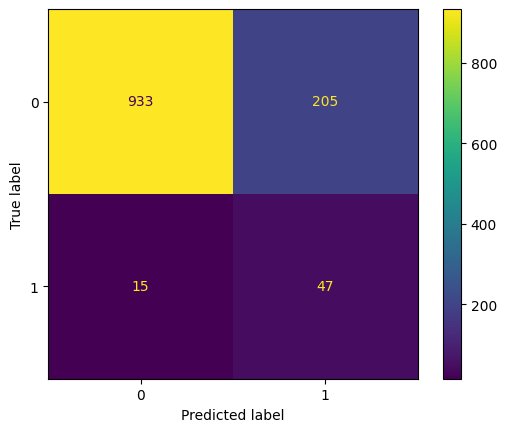

In [67]:
ConfusionMatrixDisplay.from_predictions(y_test, preds_final);